In [1]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["TORCH_COMPILE_DISABLE"] = "1"
os.environ["TORCHINDUCTOR_DISABLE"] = "1"


In [2]:
# === Cell 1 (REPLACE): Install deps + install Atari ROMs ===

!pip -q install "gymnasium[atari]" "autorom[accept-rom-license]" tqdm pandas

import shutil, sys

# AutoROM should be available as a CLI executable
print("AutoROM executable:", shutil.which("AutoROM"))

# Run ROM installer (this is the correct way)
!AutoROM --accept-license --quiet

# Quick sanity import
import gymnasium as gym
print("Gymnasium:", gym.__version__)

import os, json, math, time, random
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 34.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
AutoROM executable: /usr/local/bin/AutoROM
AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Gymnasium: 1.2.3


In [3]:
# === Repair Atari / ALE install + registration ===
!pip -q install -U "gymnasium[atari]" "ale-py" "autorom[accept-rom-license]"

# Important: importing ale_py (and/or gymnasium.envs.atari) triggers ALE registration in some setups
import ale_py
import gymnasium as gym

try:
    import gymnasium.envs.atari  # forces Atari env registration in some gymnasium builds
except Exception as e:
    print("gymnasium.envs.atari import issue (often ok):", repr(e))

print("ale-py version:", getattr(ale_py, "__version__", "unknown"))
print("Has ALE/Pong-v5 registered?:", "ALE/Pong-v5" in gym.registry)

# Quick test
env = gym.make("ALE/Pong-v5", full_action_space=True, frameskip=1, repeat_action_probability=0.0)
obs, _ = env.reset()
env.close()
print("ALE env creation OK ✅")


gymnasium.envs.atari import issue (often ok): ModuleNotFoundError("No module named 'gymnasium.envs.atari'")
ale-py version: 0.11.2
Has ALE/Pong-v5 registered?: True
ALE env creation OK ✅


In [4]:
# === Cell 2: Mount Drive + set paths ===
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/ewc_atari_3games_v2"
os.makedirs(BASE_DIR, exist_ok=True)

print("Saving to:", BASE_DIR)


Mounted at /content/drive
Saving to: /content/drive/MyDrive/ewc_atari_3games_v2


In [5]:
# === Cell 3: Config ===

@dataclass
class Config:
    # 3 games (you can swap these if you like)
    games: Tuple[str, ...] = ("ALE/Pong-v5", "ALE/Breakout-v5", "ALE/SpaceInvaders-v5")

    # Simple repeating schedule (like the paper: games return multiple times)
    # paper: randomized schedule with returns; we use deterministic for reproducibility
    schedule: Tuple[int, ...] = tuple([0,1,2]*6)

    # Total training per segment (env steps; each step uses action_repeat=4 frames)
    segment_steps: int = 70_000

    # Eval episodes per game after each segment
    eval_episodes: int = 5

    # DQN basics (paper table: discount=0.99, action repeat=4, history length=4) :contentReference[oaicite:2]{index=2}
    gamma: float = 0.99
    action_repeat: int = 4
    history_len: int = 4
    obs_size: int = 84

    # Optimization (paper uses RMSProp lr=2.5e-4, decay=0.95, grad clip etc.) :contentReference[oaicite:3]{index=3}
    lr: float = 2.5e-4
    rmsprop_alpha: float = 0.95
    rmsprop_eps: float = 1e-6
    grad_clip_norm: float = 50.0  # paper uses max norm 50 :contentReference[oaicite:4]{index=4}

    batch_size: int = 32
    replay_period: int = 4  # paper: minibatch every 4 steps :contentReference[oaicite:5]{index=5}
    target_update_period: int = 7_500  # paper: 7500 steps; slightly smaller for faster adaptation :contentReference[oaicite:6]{index=6}

    # Replay buffer per task (paper used separate buffers per task) :contentReference[oaicite:7]{index=7}
    replay_capacity: int = 10_000  # scaled down for Colab RAM/time
    learn_starts: int = 10_000      # scaled down from 50k (paper) :contentReference[oaicite:8]{index=8}

    # Per-task epsilon schedule (paper: eps=1 for 5e4 steps then decay over 1e6) :contentReference[oaicite:9]{index=9}
    # We scale down by ~50x to fit runtime.
    eps_init: float = 1.0
    eps_final: float = 0.01
    eps_hold_steps: int = 10_000
    eps_decay_steps: int = 100_000  # linear decay after hold

    # EWC specifics (paper: fisher minibatches=100, multiplier=400, start EWC after 20M frames) :contentReference[oaicite:10]{index=10}
    fisher_batches: int = 40        # scaled down for speed
    fisher_multiplier: float = 400.0 # start here; tune as noted below
    protect_after_steps: int = 160_000 # scaled-down analog of 20M frames threshold

    seed: int = 0

CFG = Config()

# --- Tuning notes (quick) ---
# If EWC curve does NOT separate from SGD (forgetting still strong): increase fisher_multiplier (e.g. 200-400).
# If EWC learns new games too slowly / plateaus early: decrease fisher_multiplier (e.g. 50-100) or increase segment_steps.
# If learning is unstable: increase replay_capacity (e.g. 5000-10000) and/or target_update_period.

print(CFG)


Config(games=('ALE/Pong-v5', 'ALE/Breakout-v5', 'ALE/SpaceInvaders-v5'), schedule=(0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2), segment_steps=70000, eval_episodes=5, gamma=0.99, action_repeat=4, history_len=4, obs_size=84, lr=0.00025, rmsprop_alpha=0.95, rmsprop_eps=1e-06, grad_clip_norm=50.0, batch_size=32, replay_period=4, target_update_period=7500, replay_capacity=10000, learn_starts=10000, eps_init=1.0, eps_final=0.01, eps_hold_steps=10000, eps_decay_steps=100000, fisher_batches=40, fisher_multiplier=400.0, protect_after_steps=160000, seed=0)


In [6]:
# === Cell 4 (REPLACE): Env utilities (robust across gymnasium versions) ===

import gymnasium as gym
import numpy as np
import torch
from typing import Dict

from gymnasium.wrappers import AtariPreprocessing

# Gymnasium wrapper name differs by version
try:
    from gymnasium.wrappers import FrameStackObservation as FrameStack
except ImportError:
    from gymnasium.wrappers import FrameStack  # older gymnasium

def make_env(env_id: str, seed: int):
    # Base ALE env. Keep frameskip=1; AtariPreprocessing applies action repeat.
    env = gym.make(
        env_id,
        full_action_space=True,
        frameskip=1,
        repeat_action_probability=0.0
    )

    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=CFG.action_repeat,  # action repeat (4)
        screen_size=CFG.obs_size,      # 84x84
        grayscale_obs=True
    )

    # Stack last 4 processed frames
    env = FrameStack(env, CFG.history_len)

    env.reset(seed=seed)
    return env

def obs_to_uint8(obs):
    """
    Return uint8 array in shape (4, 84, 84), regardless of wrapper layout.
    """
    arr = np.asarray(obs)

    # Common cases:
    # 1) (4,84,84) -> already good
    # 2) (84,84,4) -> transpose
    # 3) (4,84,84,1) or (84,84,1,4) -> squeeze then transpose as needed
    if arr.ndim == 3:
        if arr.shape[0] == CFG.history_len:              # (4,84,84)
            pass
        elif arr.shape[-1] == CFG.history_len:           # (84,84,4)
            arr = np.transpose(arr, (2, 0, 1))
        else:
            raise ValueError(f"Unexpected obs shape: {arr.shape}")
    elif arr.ndim == 4:
        arr = np.squeeze(arr)  # drop singleton channel if present
        if arr.ndim == 3 and arr.shape[-1] == CFG.history_len:
            arr = np.transpose(arr, (2, 0, 1))
        elif arr.ndim == 3 and arr.shape[0] == CFG.history_len:
            pass
        else:
            raise ValueError(f"Unexpected obs shape after squeeze: {arr.shape}")
    else:
        raise ValueError(f"Unexpected obs ndim: {arr.ndim}, shape: {arr.shape}")

    return arr.astype(np.uint8)

@torch.no_grad()
def evaluate_agent(agent, envs: Dict[str, gym.Env], episodes_per_game: int, device: str) -> Dict[str, float]:
    agent.q_net.eval()
    results = {}

    for gid, env in envs.items():
        returns = []
        for _ in range(episodes_per_game):
            obs, _ = env.reset()
            done = False
            ep_ret = 0.0

            while not done:
                o = torch.tensor(obs_to_uint8(obs), device=device).float().unsqueeze(0) / 255.0
                a = agent.act(o, task_id=agent.game_to_task[gid], epsilon=0.0)

                obs, r, terminated, truncated, _ = env.step(a)
                done = terminated or truncated
                ep_ret += float(r)

            returns.append(ep_ret)

        results[gid] = float(np.mean(returns))

    agent.q_net.train()
    return results


In [7]:
# === Cell 5: Replay buffer ===

class ReplayBuffer:
    def __init__(self, capacity: int, obs_shape=(4,84,84)):
        self.capacity = capacity
        self.obs = np.empty((capacity, *obs_shape), dtype=np.uint8)
        self.next_obs = np.empty((capacity, *obs_shape), dtype=np.uint8)
        self.actions = np.empty((capacity,), dtype=np.int64)
        self.rewards = np.empty((capacity,), dtype=np.float32)
        self.dones = np.empty((capacity,), dtype=np.bool_)
        self.idx = 0
        self.size = 0

    def add(self, obs, action, reward, next_obs, done):
        self.obs[self.idx] = obs
        self.next_obs[self.idx] = next_obs
        self.actions[self.idx] = action
        self.rewards[self.idx] = reward
        self.dones[self.idx] = done

        self.idx = (self.idx + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int, device: str):
        idxs = np.random.randint(0, self.size, size=batch_size)
        obs = torch.tensor(self.obs[idxs], device=device).float() / 255.0
        next_obs = torch.tensor(self.next_obs[idxs], device=device).float() / 255.0
        actions = torch.tensor(self.actions[idxs], device=device)
        rewards = torch.tensor(self.rewards[idxs], device=device)
        dones = torch.tensor(self.dones[idxs].astype(np.float32), device=device)
        return obs, actions, rewards, next_obs, dones


In [8]:
# === Cell 6: DQN model with task-specific gains+biases (paper Eq. 4 idea) ===
# We keep this lightweight: task-specific affine params per layer output channel/unit.
# This matches the paper's idea of per-task gains & biases (but we do not EWC-penalize them). :contentReference[oaicite:15]{index=15}

class TaskAffine(nn.Module):
    def __init__(self, num_tasks: int, num_features: int, is_conv: bool):
        super().__init__()
        self.is_conv = is_conv
        self.bias = nn.Embedding(num_tasks, num_features)
        self.gain = nn.Embedding(num_tasks, num_features)
        nn.init.zeros_(self.bias.weight)
        nn.init.ones_(self.gain.weight)

    def forward(self, x, task_id: int):
        b = self.bias(torch.tensor(task_id, device=x.device))
        g = self.gain(torch.tensor(task_id, device=x.device))
        if self.is_conv:
            # x: (B,C,H,W)
            return (x + b.view(1, -1, 1, 1)) * g.view(1, -1, 1, 1)
        else:
            # x: (B,F)
            return (x + b.view(1, -1)) * g.view(1, -1)

class QNet(nn.Module):
    def __init__(self, num_actions: int, num_tasks: int):
        super().__init__()
        # Slightly smaller than paper's bigger net, but same overall structure.
        self.conv1 = nn.Conv2d(4, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.fc = nn.Linear(64 * 7 * 7, 512)
        self.head = nn.Linear(512, num_actions)

        self.ta1 = TaskAffine(num_tasks, 32, is_conv=True)
        self.ta2 = TaskAffine(num_tasks, 64, is_conv=True)
        self.ta3 = TaskAffine(num_tasks, 64, is_conv=True)
        self.ta4 = TaskAffine(num_tasks, 512, is_conv=False)

    def forward(self, x, task_id: int):
        x = F.relu(self.ta1(self.conv1(x), task_id))
        x = F.relu(self.ta2(self.conv2(x), task_id))
        x = F.relu(self.ta3(self.conv3(x), task_id))
        x = x.view(x.size(0), -1)
        x = F.relu(self.ta4(self.fc(x), task_id))
        return self.head(x)

def shared_parameters(model: QNet):
    # Only penalize shared weights; exclude task-specific gains/biases
    for name, p in model.named_parameters():
        if name.startswith("ta"):
            continue
        yield name, p


In [9]:
# === Cell 7: DQN Agent with EWC ===

class DQNAgent:
    def __init__(self, games: Tuple[str, ...], num_actions: int, device: str,
                 fisher_multiplier: float = 0.0):
        self.device = device
        self.games = games
        self.game_to_task = {g:i for i,g in enumerate(games)}
        self.num_tasks = len(games)
        self.num_actions = num_actions

        self.q_net = QNet(num_actions=num_actions, num_tasks=self.num_tasks).to(device)
        self.target_net = QNet(num_actions=num_actions, num_tasks=self.num_tasks).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.opt = torch.optim.RMSprop(
            list(self.q_net.parameters()),
            lr=CFG.lr, alpha=CFG.rmsprop_alpha, eps=CFG.rmsprop_eps, momentum=0.0
        )

        self.fisher_multiplier = fisher_multiplier

        # per-task replay buffers
        self.buffers = {g: ReplayBuffer(CFG.replay_capacity, obs_shape=(4,84,84)) for g in games}

        # per-task step counters for epsilon schedule (paper kept separate timers) :contentReference[oaicite:16]{index=16}
        self.task_steps = {g: 0 for g in games}

        # EWC storage: per task -> (anchor params, fisher diag), only for shared params
        self.ewc_anchor: Dict[str, Dict[str, torch.Tensor]] = {}
        self.ewc_fisher: Dict[str, Dict[str, torch.Tensor]] = {}

        self.global_steps = 0

    def epsilon_for_task(self, game_id: str):
        t = self.task_steps[game_id]
        if t < CFG.eps_hold_steps:
            return CFG.eps_init
        t2 = min(max(t - CFG.eps_hold_steps, 0), CFG.eps_decay_steps)
        frac = t2 / float(CFG.eps_decay_steps)
        return CFG.eps_init + frac * (CFG.eps_final - CFG.eps_init)

    @torch.no_grad()
    def act(self, obs_t: torch.Tensor, task_id: int, epsilon: float):
        if random.random() < epsilon:
            return random.randrange(self.num_actions)
        q = self.q_net(obs_t, task_id=task_id)
        return int(torch.argmax(q, dim=1).item())

    def td_loss(self, obs, actions, rewards, next_obs, dones, task_id: int):
        # Q(s,a)
        q = self.q_net(obs, task_id=task_id).gather(1, actions.view(-1,1)).squeeze(1)

        with torch.no_grad():
            # Double DQN: argmax using online net, value using target net
            next_actions = torch.argmax(self.q_net(next_obs, task_id=task_id), dim=1)
            q_next = self.target_net(next_obs, task_id=task_id).gather(1, next_actions.view(-1,1)).squeeze(1)
            target = rewards + (1.0 - dones) * CFG.gamma * q_next

        return F.smooth_l1_loss(q, target)

    def ewc_penalty(self, current_game_id: str):
        if self.fisher_multiplier <= 0:
            return torch.tensor(0.0, device=self.device)

        penalty = torch.tensor(0.0, device=self.device)

        for game_id in self.ewc_anchor.keys():
            # KEY FIX: do NOT penalize the game you're currently training
            if game_id == current_game_id:
                continue

            if self.task_steps[game_id] < CFG.protect_after_steps:
                continue

            anchor = self.ewc_anchor[game_id]
            fisher = self.ewc_fisher[game_id]

            for name, p in shared_parameters(self.q_net):
                penalty = penalty + (fisher[name] * (p - anchor[name]).pow(2)).sum()

        return 0.5 * self.fisher_multiplier * penalty


    def learn_step(self, game_id: str):
        buf = self.buffers[game_id]
        if buf.size < max(CFG.learn_starts, CFG.batch_size):
            return None

        task_id = self.game_to_task[game_id]
        obs, actions, rewards, next_obs, dones = buf.sample(CFG.batch_size, self.device)

        loss_td = self.td_loss(obs, actions, rewards, next_obs, dones, task_id=task_id)
        loss = loss_td + self.ewc_penalty(game_id)

        self.opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), CFG.grad_clip_norm)
        self.opt.step()

        return float(loss_td.item()), float(loss.item())

    def recompute_fisher_for_task(self, game_id: str):
        # paper: fisher recomputed at task switches using minibatches from replay
        buf = self.buffers[game_id]
        if buf.size < max(CFG.learn_starts, CFG.batch_size):
            return

        task_id = self.game_to_task[game_id]
        fisher_acc = {name: torch.zeros_like(p, device=self.device) for name, p in shared_parameters(self.q_net)}

        self.q_net.eval()
        for _ in range(CFG.fisher_batches):
            obs, actions, rewards, next_obs, dones = buf.sample(CFG.batch_size, self.device)

            self.opt.zero_grad(set_to_none=True)
            loss = self.td_loss(obs, actions, rewards, next_obs, dones, task_id=task_id)
            loss.backward()

            for name, p in shared_parameters(self.q_net):
                if p.grad is None:
                    continue
                fisher_acc[name] += (p.grad.detach() ** 2)

        for name in fisher_acc:
            fisher_acc[name] /= float(CFG.fisher_batches)

        # store anchor + fisher (detach/cpu for saving later)
        anchor = {name: p.detach().clone() for name, p in shared_parameters(self.q_net)}
        self.ewc_anchor[game_id] = anchor
        self.ewc_fisher[game_id] = fisher_acc

        self.q_net.train()


In [10]:
# === Cell 8: Save / Load checkpoints ===

def ckpt_path(method: str):
    return os.path.join(BASE_DIR, f"{method}_checkpoint.pt")

def log_path(method: str):
    return os.path.join(BASE_DIR, f"{method}_eval_log.csv")

def save_checkpoint(method: str, agent: DQNAgent, segment_idx: int):
    payload = {
        "segment_idx": segment_idx,
        "global_steps": agent.global_steps,
        "task_steps": agent.task_steps,

        "q_net": agent.q_net.state_dict(),
        "target_net": agent.target_net.state_dict(),
        "opt": agent.opt.state_dict(),

        # EWC stats (shared params only)
        "ewc_anchor": {g: {k: v.detach().cpu() for k,v in d.items()} for g,d in agent.ewc_anchor.items()},
        "ewc_fisher": {g: {k: v.detach().cpu() for k,v in d.items()} for g,d in agent.ewc_fisher.items()},

        "config": asdict(CFG),
    }
    torch.save(payload, ckpt_path(method))
    print(f"[{method}] saved checkpoint at segment {segment_idx} -> {ckpt_path(method)}")

def load_checkpoint(method: str, agent: DQNAgent):
    path = ckpt_path(method)
    if not os.path.exists(path):
        return None

    payload = torch.load(path, map_location=agent.device)
    agent.q_net.load_state_dict(payload["q_net"])
    agent.target_net.load_state_dict(payload["target_net"])
    agent.opt.load_state_dict(payload["opt"])
    agent.global_steps = int(payload["global_steps"])
    agent.task_steps = {k:int(v) for k,v in payload["task_steps"].items()}

    # restore EWC tensors to device
    agent.ewc_anchor = {
        g: {k: v.to(agent.device) for k,v in d.items()}
        for g,d in payload.get("ewc_anchor", {}).items()
    }
    agent.ewc_fisher = {
        g: {k: v.to(agent.device) for k,v in d.items()}
        for g,d in payload.get("ewc_fisher", {}).items()
    }
    print(f"[{method}] loaded checkpoint from segment {payload['segment_idx']} (global_steps={agent.global_steps})")
    return int(payload["segment_idx"])

def append_eval_log(method: str, segment_idx: int, frames: int, eval_returns: Dict[str, float]):
    rows = []
    for g, r in eval_returns.items():
        rows.append({
            "method": method,
            "segment_idx": segment_idx,
            "frames": frames,
            "game": g,
            "mean_return": r,
        })
    df = pd.DataFrame(rows)
    out = log_path(method)
    header = not os.path.exists(out)
    df.to_csv(out, mode="a", header=header, index=False)


In [11]:
# === Cell 9: Training loop (one method) ===

def train_method(method: str, fisher_multiplier: float, resume: bool = True):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)

    # create envs once
    envs = {g: make_env(g, seed=CFG.seed + i) for i, g in enumerate(CFG.games)}
    num_actions = envs[CFG.games[0]].action_space.n
    print("Num actions:", num_actions)

    agent = DQNAgent(CFG.games, num_actions=num_actions, device=device,
                     fisher_multiplier=fisher_multiplier)

    start_segment = 0
    if resume:
        loaded = load_checkpoint(method, agent)
        if loaded is not None:
            start_segment = loaded + 1

    # main schedule
    for seg_idx in range(start_segment, len(CFG.schedule)):
        game_id = CFG.games[CFG.schedule[seg_idx]]
        env = envs[game_id]

        # start each segment with a fresh episode (simplifies; still shows forgetting)
        obs, _ = env.reset()

        pbar = tqdm(range(CFG.segment_steps), desc=f"[{method}] seg {seg_idx} | {game_id}", leave=False)
        for _ in pbar:
            eps = agent.epsilon_for_task(game_id)
            task_id = agent.game_to_task[game_id]

            obs_u8 = obs_to_uint8(obs)
            obs_t = torch.tensor(obs_u8, device=device).float().unsqueeze(0) / 255.0
            action = agent.act(obs_t, task_id=task_id, epsilon=eps)

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # reward clipping (paper: max reward 1) :contentReference[oaicite:18]{index=18}
            r = float(np.clip(reward, -1.0, 1.0))

            agent.buffers[game_id].add(obs_u8, action, r, obs_to_uint8(next_obs), done)

            agent.task_steps[game_id] += 1
            agent.global_steps += 1

            # learn
            if agent.global_steps % CFG.replay_period == 0:
                out = agent.learn_step(game_id)
                if out is not None:
                    td, total = out
                    pbar.set_postfix({"eps": f"{eps:.3f}", "td": f"{td:.3f}", "L": f"{total:.3f}"})

            # target net update
            if agent.global_steps % CFG.target_update_period == 0:
                agent.target_net.load_state_dict(agent.q_net.state_dict())

            if done:
                obs, _ = env.reset()
            else:
                obs = next_obs

        # task switch: recompute fisher for the task we just trained on
        # (paper recomputes at each switch; EWC penalty only for tasks above threshold)
        # EWC: compute Fisher only once per game, when it first becomes protected
        if fisher_multiplier > 0:
            agent.recompute_fisher_for_task(game_id)



        # evaluation after each segment -> CHANGE to every 2 segments
        do_eval = (seg_idx % 2 == 1) or (seg_idx == len(CFG.schedule) - 1)
        if do_eval:
            frames = agent.global_steps * CFG.action_repeat
            eval_returns = evaluate_agent(agent, envs, CFG.eval_episodes, device=device)
            append_eval_log(method, seg_idx, frames, eval_returns)


        # checkpoint
        save_checkpoint(method, agent, seg_idx)

    for e in envs.values():
        e.close()

    print(f"[{method}] done. Eval log at: {log_path(method)}")


In [ ]:
# === Cell 10A: Train SGD only ===
train_method(method="sgd", fisher_multiplier=0.0, resume=True)


In [12]:
# === Cell 10B: Train EWC only ===
train_method(method="ewc", fisher_multiplier=CFG.fisher_multiplier, resume=True)


Device: cuda
Num actions: 18
[ewc] loaded checkpoint from segment 9 (global_steps=700000)


[ewc] seg 10 | ALE/Breakout-v5:   0%|          | 0/70000 [00:00<?, ?it/s]

[ewc] saved checkpoint at segment 10 -> /content/drive/MyDrive/ewc_atari_3games_v2/ewc_checkpoint.pt


[ewc] seg 11 | ALE/SpaceInvaders-v5:   0%|          | 0/70000 [00:00<?, ?it/s]

[ewc] saved checkpoint at segment 11 -> /content/drive/MyDrive/ewc_atari_3games_v2/ewc_checkpoint.pt


...

[ewc] saved checkpoint at segment 15 -> /content/drive/MyDrive/ewc_atari_3games_v2/ewc_checkpoint.pt


[ewc] seg 16 | ALE/Breakout-v5:   0%|          | 0/70000 [00:00<?, ?it/s]

[ewc] saved checkpoint at segment 16 -> /content/drive/MyDrive/ewc_atari_3games_v2/ewc_checkpoint.pt


[ewc] seg 17 | ALE/SpaceInvaders-v5:   0%|          | 0/70000 [00:00<?, ?it/s]

[ewc] saved checkpoint at segment 17 -> /content/drive/MyDrive/ewc_atari_3games_v2/ewc_checkpoint.pt
[ewc] done. Eval log at: /content/drive/MyDrive/ewc_atari_3games_v2/ewc_eval_log.csv


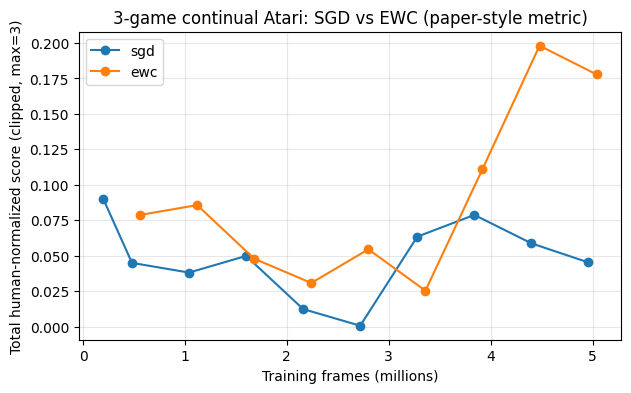

In [6]:
# === Cell 11 (REPLACE): Plot paper-style total human-normalized (clipped) score ===
import matplotlib.pyplot as plt
import pandas as pd
import os

def load_logs():
    dfs = []
    for method in ["sgd", "ewc"]:
        p = log_path(method)
        if os.path.exists(p):
            dfs.append(pd.read_csv(p))
    if not dfs:
        raise FileNotFoundError("No eval logs found. Run training first.")
    return pd.concat(dfs, ignore_index=True)

df = load_logs()

# Random & human scores (normalization constants)
# Pong: -20.71 / 14.6, Breakout: 1.72 / 30.5, Space Invaders: 148.3 / 1668.7 :contentReference[oaicite:5]{index=5}
RANDOM_HUMAN = {
    "ALE/Pong-v5": (-20.71, 14.6),
    "ALE/Breakout-v5": (1.72, 30.5),
    "ALE/SpaceInvaders-v5": (148.3, 1668.7),
}

def human_normalized(game, score):
    r, h = RANDOM_HUMAN[game]
    return (score - r) / (h - r + 1e-9)

df["hns"] = df.apply(lambda row: human_normalized(row["game"], row["mean_return"]), axis=1)
df["clipped"] = df["hns"].clip(0.0, 1.0)

tot = (
    df.groupby(["method","segment_idx","frames"])["clipped"]
      .sum()
      .reset_index()
      .sort_values(["method","frames"])
)

# light smoothing to reduce eval noise
tot["smoothed"] = tot.groupby("method")["clipped"].transform(lambda s: s.rolling(2, min_periods=1).mean())

plt.figure(figsize=(7,4))
for method in ["sgd","ewc"]:
    sub = tot[tot["method"] == method]
    plt.plot(sub["frames"]/1e6, sub["smoothed"], marker="o", label=method)

plt.xlabel("Training frames (millions)")
plt.ylabel("Total human-normalized score (clipped, max=3)")
plt.title("3-game continual Atari: SGD vs EWC (paper-style metric)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


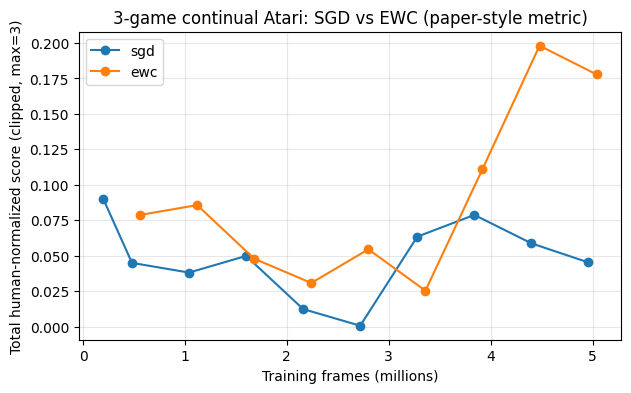

In [8]:
# === Cell 12 (REPLACE): Re-plot paper-style metric from Drive logs ===
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/content/drive/MyDrive/ewc_atari_3games_v2"

def log_path(method: str):
    return os.path.join(BASE_DIR, f"{method}_eval_log.csv")

dfs = []
for method in ["sgd", "ewc"]:
    p = log_path(method)
    if os.path.exists(p):
        d = pd.read_csv(p)
        d["method"] = method
        dfs.append(d)

df = pd.concat(dfs, ignore_index=True)

# --- IMPORTANT: keep only the latest record per (method, frames, game)
# This removes duplicates from resume / reruns.
df = df.sort_values(["method","frames","game"]).drop_duplicates(
    subset=["method","frames","game"], keep="last"
)

RANDOM_HUMAN = {
    "ALE/Pong-v5": (-20.71, 14.6),
    "ALE/Breakout-v5": (1.72, 30.5),
    "ALE/SpaceInvaders-v5": (148.3, 1668.7),
}

def human_normalized(game, score):
    r, h = RANDOM_HUMAN[game]
    return (score - r) / (h - r + 1e-9)

df["hns"] = df.apply(lambda row: human_normalized(row["game"], row["mean_return"]), axis=1)
df["clipped"] = df["hns"].clip(0.0, 1.0)

tot = (
    df.groupby(["method","frames"])["clipped"]
      .sum()
      .reset_index()
      .sort_values(["method","frames"])
)

tot["smoothed"] = tot.groupby("method")["clipped"].transform(lambda s: s.rolling(2, min_periods=1).mean())

plt.figure(figsize=(7,4))
for method in ["sgd","ewc"]:
    sub = tot[tot["method"] == method]
    plt.plot(sub["frames"]/1e6, sub["smoothed"], marker="o", label=method)

plt.xlabel("Training frames (millions)")
plt.ylabel("Total human-normalized score (clipped, max=3)")
plt.title("3-game continual Atari: SGD vs EWC (paper-style metric)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
